# طبقه‌بندی توده‌های سرطان سینه با الگوریتم KNN

در این پروژه از الگوریتم **K-Nearest Neighbors (KNN)** برای تشخیص نوع توده‌های سرطان سینه استفاده می‌کنیم.  
هدف این است که مدل بتواند با توجه به ویژگی‌های عددی سلول‌ها، تشخیص دهد نمونه‌ی ورودی **خوش‌خیم (benign)** است یا **بدخیم (malignant)**.

در این نوت‌بوک دو روش برای انتخاب بهترین مقدار \(K\) بررسی شده است:

1. **جست‌وجوی دستی** روی مقادیر مختلف \(K\)
2. **GridSearchCV** برای انتخاب خودکار بهترین \(K\)

در پایان، عملکرد مدل با معیارهایی مثل **Accuracy، Precision، Recall، F1-score** و **Confusion Matrix** ارزیابی می‌شود.


## صورت مسئله

در پزشکی، تشخیص سریع و دقیق تومورهای سرطانی اهمیت بسیار زیادی دارد.  
اگر مدل بتواند با دقت بالا نوع توده را تشخیص دهد، می‌تواند به پزشک در تصمیم‌گیری کمک کند.

در این مسئله:

- **ورودی:** ویژگی‌های سلول‌های توده
- **خروجی:** یکی از دو کلاس زیر:
  - **malignant** → بدخیم
  - **benign** → خوش‌خیم

از آنجا که داده‌ها عددی هستند و مسئله از نوع **طبقه‌بندی** است، الگوریتم 
**KNN** یک انتخاب ساده و مناسب برای شروع محسوب می‌شود.


## الگوریتم KNN چیست؟

الگوریتم **K-Nearest Neighbors** یکی از ساده‌ترین الگوریتم‌های یادگیری ماشین است.  
ایده‌ی اصلی آن این است:

> یک نمونه‌ی جدید را بر اساس برچسب **نزدیک‌ترین همسایه‌هایش** پیش‌بینی کن.

### نحوه‌ی کار:
- برای یک نمونه‌ی جدید، فاصله‌ی آن با تمام نمونه‌های آموزشی محاسبه می‌شود.
- \(K\) نمونه‌ی نزدیک‌تر انتخاب می‌شوند.
- برچسبی که در بین آن \(K\) همسایه بیشتر تکرار شده باشد، به نمونه‌ی جدید اختصاص داده می‌شود.

### نکته‌ی مهم:
انتخاب مقدار \(K\) بسیار مهم است:
- \(K\) خیلی کوچک → مدل بیش‌ازحد حساس می‌شود
- \(K\) خیلی بزرگ → مدل بیش‌ازحد ساده می‌شود

به همین دلیل، در این پروژه بهترین مقدار \(K\) بررسی و انتخاب می‌شود.


## وارد کردن کتابخانه‌ها

در این بخش کتابخانه‌های موردنیاز وارد می‌شوند:

- `numpy` برای محاسبات عددی
- `pandas` برای کار با داده‌ها
- `matplotlib` و `seaborn` برای رسم نمودار
- `scikit-learn` برای آماده‌سازی داده‌ها، ساخت مدل و ارزیابی آن


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

## بارگذاری دیتاست Breast Cancer

در این پروژه از دیتاست آماده‌ی `breast_cancer` در کتابخانه‌ی scikit-learn استفاده شده است.

این دیتاست شامل:
- **569 نمونه**
- **30 ویژگی عددی**
- **2 کلاس خروجی**:
  - malignant
  - benign

این داده‌ها برای مسئله‌ی طبقه‌بندی بسیار مناسب هستند، چون هم اندازه‌ی قابل‌قبولی دارند و هم ساختار استانداردی برای آزمایش الگوریتم‌های یادگیری ماشین فراهم می‌کنند.


In [5]:
# 1. Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset shape: {X.shape}")
print(f"Classes: {target_names}")


Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


## تقسیم داده‌ها

داده‌ها به دو بخش تقسیم می‌شوند:

- **70٪ برای آموزش**
- **30٪ برای آزمون**

### چرا این کار مهم است؟
اگر مدل فقط روی داده‌های آموزشی ارزیابی شود، نمی‌توان فهمید که آیا واقعاً یاد گرفته یا فقط داده‌ها را حفظ کرده است.  
بنابراین یک مجموعه‌ی جداگانه برای آزمون لازم است تا عملکرد مدل روی داده‌های جدید سنجیده شود.

### نکته:
در این پروژه از `stratify=y` استفاده شده است تا نسبت کلاس‌ها در هر دو بخش آموزش و آزمون حفظ شود.


In [ ]:
# 2. Split Data into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## استانداردسازی ویژگی‌ها

در الگوریتم KNN، فاصله‌ها نقش اصلی دارند.  
به همین دلیل اگر ویژگی‌ها مقیاس‌های متفاوتی داشته باشند، ویژگی‌هایی که عدد بزرگ‌تری دارند اثر بیشتری روی مدل می‌گذارند و این باعث خطا می‌شود.

برای جلوگیری از این مشکل از `StandardScaler` استفاده شده است.

### StandardScaler چه می‌کند؟
هر ویژگی را به شکلی تبدیل می‌کند که:
- میانگین آن حدوداً صفر شود
- انحراف معیار آن 1 شود

### نتیجه:
همه‌ی ویژگی‌ها در یک مقیاس قرار می‌گیرند و KNN منصفانه‌تر عمل می‌کند.


In [ ]:
# 3. Feature Scaling (Crucial for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## روش اول: بررسی دستی مقادیر مختلف K

در این بخش، مقدارهای فرد از 1 تا 29 برای \(K\) بررسی می‌شوند.

### چرا فقط عدد فرد؟
چون در مسئله‌ی دودویی مانند این پروژه، اگر \(K\) زوج باشد ممکن است در رأی‌گیری بین دو کلاس تساوی ایجاد شود.  
برای جلوگیری از این مشکل، از عددهای فرد استفاده شده است.

### مراحل انجام کار:
1. برای هر \(K\)، مدل KNN آموزش داده می‌شود.
2. دقت روی داده‌ی آموزش و آزمون محاسبه می‌شود.
3. بهترین \(K\) بر اساس **بالاترین دقت روی داده‌ی آزمون** انتخاب می‌شود.
4. نمودار تغییر دقت‌ها رسم می‌شود.


In [6]:

# 4. Investigate the effect of K on Accuracy
k_values = range(1, 31, 2)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Predict on training set
    y_train_pred = knn.predict(X_train_scaled)
    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    
    # Predict on test set
    y_test_pred = knn.predict(X_test_scaled)
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

# 5. Find the optimal K (Max Test Accuracy)
best_k_idx = np.argmax(test_accuracies)
best_k = k_values[best_k_idx]
best_score = test_accuracies[best_k_idx]

print(f"\nOptimal K found: {best_k}")
print(f"Best Test Accuracy: {best_score:.4f}")
 


Optimal K found: 7
Best Test Accuracy: 0.9649


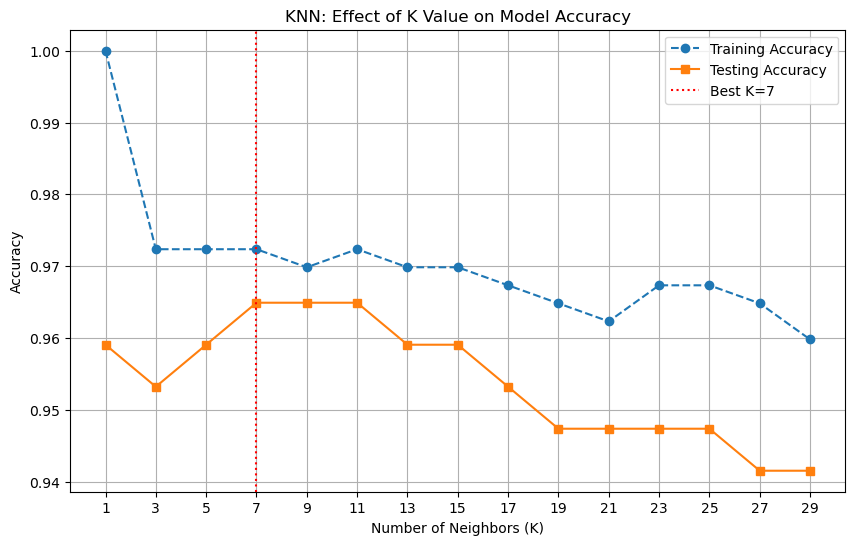


Training Final Model with K=7...

Classification Report (Test Set):
              precision    recall  f1-score   support

   malignant       1.00      0.91      0.95        64
      benign       0.95      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171


Confusion Matrix
[[ 58   6]
 [  0 107]]


In [7]:

# 6. Visualization
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Training Accuracy', marker='o', linestyle='--')
plt.plot(k_values, test_accuracies, label='Testing Accuracy', marker='s')
plt.title('KNN: Effect of K Value on Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.axvline(x=best_k, color='red', linestyle=':', label=f'Best K={best_k}')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 7. Final Model Training & Evaluation with Best K
# ---------------------------------------------------------
print("\n" + "="*40)
print(f"Training Final Model with K={best_k}...")
print("="*40)

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

# Final Evaluation on Test Set
y_final_pred = final_model.predict(X_test_scaled)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_final_pred, target_names=target_names))

# Confusion Matrix 
print("\n" + "="*40)
print("Confusion Matrix")
print("="*40)
print(confusion_matrix(y_test, y_final_pred))

## نتیجه‌ی جست‌وجوی دستی

در خروجی این بخش:

- **بهترین مقدار K = 7**
- **Best Test Accuracy = 0.9649**

### تفسیر:
این یعنی وقتی \(K=7\) انتخاب شده، مدل بهترین عملکرد را روی داده‌ی آزمون داشته است.

### نکته‌ی تحلیلی:
اگر دقت آموزش خیلی بالا ولی دقت آزمون پایین باشد، مدل احتمالاً **بیش‌برازش (overfitting)** دارد.  
اگر هر دو پایین باشند، مدل **کم‌برازش (underfitting)** دارد.

در این پروژه، نتیجه نشان می‌دهد که مدل عملکرد متعادلی دارد و خوب generalize کرده است.


## ارزیابی نهایی مدل

برای ارزیابی نهایی از معیارهای زیر استفاده شده است:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **Confusion Matrix**

### تفسیر گزارش طبقه‌بندی:
- برای کلاس **malignant**:
  - Precision = 1.00
  - Recall = 0.91
  - F1-score = 0.95

- برای کلاس **benign**:
  - Precision = 0.95
  - Recall = 1.00
  - F1-score = 0.97

### دقت کلی:
- **Accuracy = 0.96**

### ماتریس درهم‌ریختگی:

\begin{bmatrix}
58 & 6 \\
0 & 107
\end{bmatrix}


### معنی این ماتریس:
- 58 نمونه‌ی بدخیم درست شناسایی شده‌اند.
- 6 نمونه‌ی بدخیم اشتباه به‌عنوان خوش‌خیم پیش‌بینی شده‌اند.
- 107 نمونه‌ی خوش‌خیم درست شناسایی شده‌اند.
- 0 نمونه‌ی خوش‌خیم به‌اشتباه بدخیم تشخیص داده شده است.

### نکته‌ی مهم:
در مسائل پزشکی، **اشتباه در شناسایی بدخیم‌ها** بسیار حساس است.  
پس اگرچه Accuracy بالا است، باید به Recall کلاس بدخیم هم توجه ویژه کرد.


## روش دوم: انتخاب بهترین K با GridSearchCV

در این بخش از `GridSearchCV` استفاده می‌شود تا بهترین مقدار \(K\) به‌صورت سیستماتیک و با **اعتبارسنجی متقاطع** انتخاب شود.

### مزیت این روش:
به‌جای اینکه فقط یک بار روی داده‌ی آزمون تصمیم بگیریم، مدل روی چند بخش مختلف از داده‌ی آموزش ارزیابی می‌شود.  
این کار باعث می‌شود انتخاب \(K\) قابل‌اعتمادتر باشد.

### تنظیمات استفاده‌شده:
- `n_neighbors` از 1 تا 29 با گام 2
- `cv = 3`
- معیار ارزیابی: `accuracy`
- `return_train_score=True`


In [ ]:
#######################

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']

Starting GridSearchCV...
Best K found: 9
Best Cross-Validation Accuracy: 0.9673


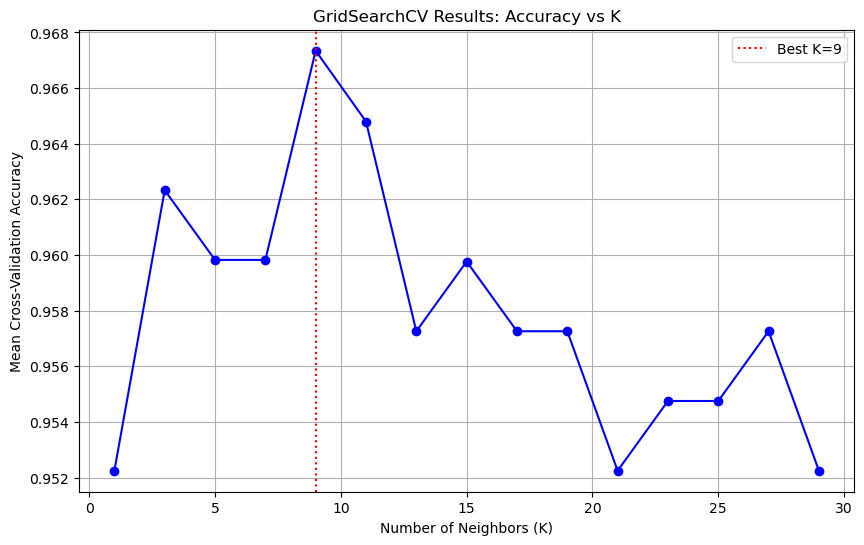


Final Evaluation on Test Set
Test Set Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.91      0.95        64
      benign       0.95      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171

[[ 58   6]
 [  0 107]]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

# 1. Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset shape: {X.shape}")
print(f"Classes: {target_names}")

# 2. Split Data into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Hyperparameter Tuning using GridSearchCV
print("\n" + "="*40)
print("Starting GridSearchCV...")
print("="*40)

pg = {'n_neighbors': range(1, 30, 2)}

gs = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=pg,
    cv=3,
    scoring='accuracy',
    return_train_score=True 
)

gs.fit(X_train_scaled, y_train)

# 5. Extract Best Parameters
best_k = gs.best_params_['n_neighbors']
best_cv_score = gs.best_score_

print(f"Best K found: {best_k}")
print(f"Best Cross-Validation Accuracy: {best_cv_score:.4f}")

# 6. Visualization of GridSearch Results
results = pd.DataFrame(gs.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(results['param_n_neighbors'], results['mean_test_score'], marker='o', linestyle='-', color='blue')
plt.title('GridSearchCV Results: Accuracy vs K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.axvline(x=best_k, color='red', linestyle=':', label=f'Best K={best_k}')
plt.legend()
plt.grid(True)
plt.show()

# 7. Final Evaluation on Test Set
# The 'gs' object automatically uses the best estimator found
y_test_pred = gs.predict(X_test_scaled)

print("\n" + "="*40)
print("Final Evaluation on Test Set")
print("="*40)

print(f"Test Set Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# Confusion Matrix
print(confusion_matrix(y_test, y_test_pred))


## نتیجه‌ی GridSearchCV

در خروجی این بخش:

- **Best K = 9**
- **Best Cross-Validation Accuracy = 0.9673**
- **Test Set Accuracy = 0.9649**

### تفسیر:
GridSearchCV مقدار 9 را به‌عنوان بهترین \(K\) بر اساس میانگین دقت اعتبارسنجی متقاطع انتخاب کرده است.

نکته‌ی جالب این است که با وجود تفاوت در مقدار بهترین \(K\)،  
دقت نهایی روی مجموعه‌ی آزمون تقریباً همان مقدار روش دستی باقی مانده است.

### نتیجه‌ی مهم:
این نشان می‌دهد که مدل در بازه‌ی مقادیر مناسب \(K\) نسبتاً پایدار است.


## مقایسه‌ی دو روش انتخاب K

در این پروژه دو روش برای انتخاب مقدار بهینه‌ی \(K\) بررسی شد:

### 1) جست‌وجوی دستی
- ساده و قابل فهم
- مناسب برای درک اولیه
- بهترین مقدار: \(K=7\)

### 2) GridSearchCV
- حرفه‌ای‌تر و دقیق‌تر
- مبتنی بر Cross-Validation
- بهترین مقدار: \(K=9\)

### نتیجه‌ی مقایسه:
با اینکه مقدار بهینه‌ی \(K\) در دو روش متفاوت بود،  
اما عملکرد نهایی هر دو تقریباً یکسان بود:

- **Accuracy نهایی: 0.9649**

این یعنی مدل نسبت به انتخاب دقیق \(K\) در این بازه خیلی حساس نیست و در محدوده‌ی مقادیر خوب، عملکرد پایدار دارد.
